
# Задачі кластеризації та класифікації


<h2>Мета</h2>

Ознайомитись з різновидами моделей для задач кластеризації та класифікації, а також методами побудови та оцінки цих моделей. Після завершення цієї лабораторної роботи ви зможете:

* Використовувати прості моделі для задач кластеризації та класифікації
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані із файлу <a href="https://drive.google.com/file/d/1wSj5SKRPKOjNPP2cyqaNpxRCinKEmJkO/view?usp=drive_link" target="_blank">'clean_data2.csv'</a> (Data2.csv з виправленими помилками та заповненими пропусками). Виконайте кластеризацію по ВВП на душу населення та щільності населення.
2. Використайте метод ліктя для підбору оптимальної кількості кластерів.
3. Визначіть, який регіон домінує в кожному з кластерів.
4. Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).
5. Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Виконайте кластеризацію по ВВП на душу населення та щільності населення. </p>
</div>


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import mean_squared_error, r2_score, classification_report, silhouette_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

Зчитую дані з файлу у датафрейм


In [10]:
path = "clean_data2.csv"
df = pd.read_csv(path)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225000,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853000,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217000,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,165114.116337,200,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042000,470,164.427660


Виділяю параметри для кластеризації

In [15]:
features = df[['GDP per capita', 'Population density']]
features

,GDP per capita,Population density
0,561.778746,53.083405
1,4124.982390,100.038296
2,3916.881571,17.048902
3,11834.745230,277.995000
4,36988.622030,164.427660
...,...,...
212,13445.593416,294.145714
213,2943.404534,756.074086
214,990.334774,52.245796
215,1269.573537,22.045136


Будую модель методом k середніх з кількістю кластерів 5

In [20]:
kmeans1 = KMeans(
    init='random',
    n_clusters=5,
    n_init=10,
    max_iter=300
)

kmeans1.fit(features)

KMeans(init='random', n_clusters=5, n_init=10)

<p>Отримані центри кластерів:</p>


In [23]:
kmeans1.cluster_centers_

array([[25288.99915571,   371.88157383],
       [43104.7268005 ,   900.26897294],
       [12994.17359244,   584.94076032],
       [ 2915.9321525 ,   123.47710559],
       [70801.76889125,  2646.54657044]])

<p>Масив із номерами кластерів для кожного рядка даних:</p>


In [26]:
kmeans1.labels_

array([3, 3, 3, 2, 1, 3, 2, 2, 3, 2, 1, 1, 3, 0, 0, 3, 2, 3, 1, 3, 3, 2,
       3, 3, 3, 3, 2, 2, 0, 3, 3, 3, 3, 3, 3, 1, 2, 3, 3, 2, 2, 2, 3, 3,
       3, 3, 2, 3, 2, 2, 2, 0, 2, 1, 2, 3, 3, 3, 3, 3, 2, 2, 2, 3, 2, 3,
       1, 1, 2, 3, 3, 3, 1, 3, 2, 2, 2, 2, 1, 3, 3, 3, 3, 3, 3, 1, 2, 4,
       3, 3, 3, 3, 4, 2, 1, 0, 3, 1, 3, 3, 3, 3, 2, 0, 3, 0, 3, 3, 2, 2,
       3, 3, 2, 2, 2, 4, 4, 3, 3, 3, 2, 2, 3, 0, 3, 3, 2, 2, 3, 3, 2, 3,
       3, 3, 3, 3, 3, 3, 3, 1, 2, 1, 3, 2, 3, 0, 4, 2, 3, 2, 2, 3, 3, 3,
       3, 2, 0, 0, 4, 2, 2, 3, 3, 1, 3, 0, 3, 3, 2, 3, 1, 2, 2, 0, 3, 3,
       3, 2, 0, 3, 2, 2, 2, 3, 3, 3, 3, 1, 4, 2, 3, 3, 3, 3, 3, 3, 2, 3,
       2, 3, 2, 3, 3, 3, 1, 1, 4, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3],
      dtype=int32)

<p>Візуалізую отримані кластери:</p>


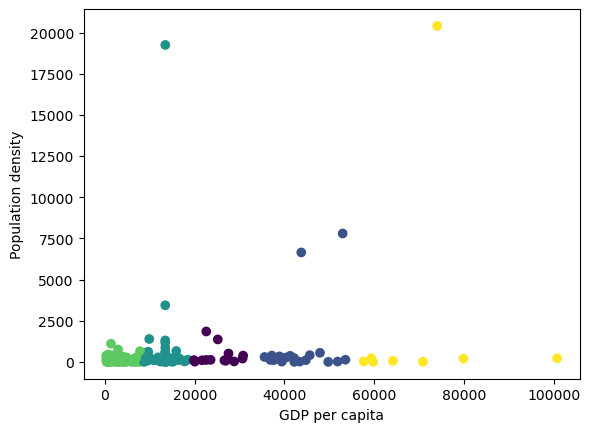

In [29]:
plt.xlabel('GDP per capita')
plt.ylabel('Population density')
plt.scatter(df[['GDP per capita']], df[['Population density']], c=kmeans1.labels_)
plt.show()

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Використайте метод ліктя для підбору оптимальної кількості кластерів.</p>
</div>


Визначаю оптимальну кількість кластерів. Скористаюсь методом "ліктя". Для цього ініціалізую алгоритм k середніх кількістю кластерів від 1 до 10 і для кожної моделі рахую суму квадратів похибок (евклідових відстаней точок кластерів від відповідних центрів):

In [36]:
kmeans_kwargs = {
    'init': 'random',
    'n_init': 10,
    'max_iter': 300,
    'random_state': 42,
}

sse = []
max_kernels = 10
for k in range(1, max_kernels + 1):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

<p>Візуалізую отримані результати:</p>


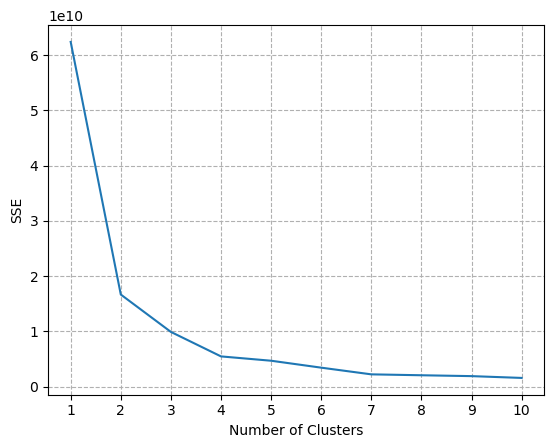

In [39]:
plt.plot(range(1, max_kernels + 1), sse)
plt.xticks(range(1, max_kernels + 1))
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.grid(linestyle='--')
plt.show()

<p>Оптимальна кількість кластерів дорівнює 4.</p>
<p>Візуалізую для оптимальної кількості кластерів:</p>

In [47]:
silhouette_coefficients = []

for k in range(2, max_kernels + 1):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(features)
    score = silhouette_score(features, kmeans.labels_)
    silhouette_coefficients.append(score)

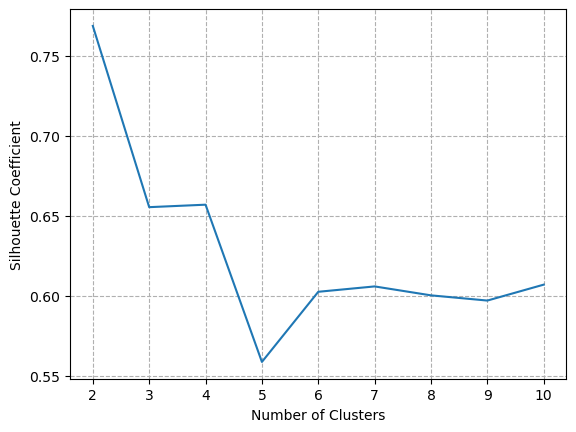

In [50]:
plt.plot(range(2, max_kernels + 1), silhouette_coefficients)
plt.xticks(range(2, max_kernels + 1))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Coefficient')
plt.grid(linestyle='--')
plt.show()

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Визначіть, який регіон домінує в кожному з кластерів.</p>
</div>


Додаю мітки кластерів в датафрейм

In [60]:
df['Cluster'] = kmeans1.labels_
df

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density,Cluster
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225000,652860,53.083405,3
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853000,28750,100.038296,3
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217000,2381740,17.048902,3
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,165114.116337,200,277.995000,2
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042000,470,164.427660,1
...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),Latin America & Caribbean,13445.593416,102951.0,165114.116337,350,294.145714,2
213,West Bank and Gaza,Middle East & North Africa,2943.404534,4551566.0,165114.116337,6020,756.074086,3
214,"Yemen, Rep.",Middle East & North Africa,990.334774,27584213.0,22698.730000,527970,52.245796,3
215,Zambia,Sub-Saharan Africa,1269.573537,16591390.0,4503.076000,752610,22.045136,3


Визначаю домінуючий регіон для кожного кластера

In [62]:
cluster_region_counts = df.groupby('Cluster')['Region'].value_counts()
dominant_regions = cluster_region_counts.groupby(level=0).idxmax()
print(dominant_regions)

Cluster
0        (0, Europe & Central Asia)
1        (1, Europe & Central Asia)
2    (2, Latin America & Caribbean)
3           (3, Sub-Saharan Africa)
4        (4, Europe & Central Asia)
Name: count, dtype: object


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте кілька (3-5) моделей класифікації, що визначають регіон, до якого належить країна, по ознаках 'GDP per capita', 'Population', 'CO2 emission', 'Area'. Оцініть точність класифікації (використайте 20% загального набору в якості тестових даних).</p>
</div>


 Обираю потрібні ознаки:


In [71]:
all_features=pd.get_dummies(df[['GDP per capita', 'Population', 'CO2 emission', 'Area']])
all_features[['Region']] = df[['Region']]

 Розділяю датасет на навчальну і тестову вибірки за допомогою функції <code>train_test_split()</code>:


In [73]:
df_train, df_test = train_test_split(
    all_features,
    test_size=0.2,
    random_state=1
)
df_train.head()

,GDP per capita,Population,CO2 emission,Area,Region
117,5237.147670,2081206.0,7510.016,25710,Europe & Central Asia
47,1534.973724,23695919.0,11045.004,322460,Sub-Saharan Africa
27,13445.593416,30661.0,179.683,150,Latin America & Caribbean
59,4223.584579,6344722.0,6285.238,21040,Latin America & Caribbean
40,13792.926050,17909754.0,82562.505,756096,Latin America & Caribbean


<p>Розміщую цільові дані - Region -  в окремому датафреймі:</p>

In [81]:
x_train = df_train[['GDP per capita', 'Population', 'CO2 emission', 'Area']]
y_train = df_train[['Region']]

x_test = df_test[['GDP per capita', 'Population', 'CO2 emission', 'Area']]
y_test = df_test[['Region']]

<h3>Навчання та тестування моделей:</h3>

Для навчання були обрані наступні методи:

- k-nearest neighbors;
- Support vector machines;
- Decision Tree;
- Random Forest;
- Extra Trees.

 <h3>k-nearest neighbors</h3>


Будую модель


In [92]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(x_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

Оцінюю точність

In [95]:
print('mean accuracy = ', KNN_model.score(x_test, y_test))

mean accuracy =  0.22727272727272727


In [102]:
print(classification_report(y_test, KNN_model.predict(x_test)))

print(confusion_matrix(y_test, KNN_model.predict(x_test)))

                            precision    recall  f1-score   support

       East Asia & Pacific       0.25      0.22      0.24         9
     Europe & Central Asia       0.18      0.21      0.19        14
 Latin America & Caribbean       0.00      0.00      0.00         8
Middle East & North Africa       0.00      0.00      0.00         3
             North America       0.00      0.00      0.00         1
                South Asia       0.00      0.00      0.00         1
        Sub-Saharan Africa       0.50      0.62      0.56         8

                  accuracy                           0.23        44
                 macro avg       0.13      0.15      0.14        44
              weighted avg       0.20      0.23      0.21        44

[[2 4 1 0 0 0 2]
 [2 3 4 1 0 1 3]
 [3 5 0 0 0 0 0]
 [0 3 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0]
 [1 2 0 0 0 0 5]]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


<h3>Support vector machines</h3>


Будую модель


In [113]:
SVC_model = SVC()
SVC_model.fit(x_train, y_train)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

Оцінюю точність

In [116]:
print('mean accuracy = ', SVC_model.score(x_test, y_test))

mean accuracy =  0.3181818181818182


In [119]:
print(classification_report(y_test, SVC_model.predict(x_test)))

print(confusion_matrix(y_test, SVC_model.predict(x_test)))

                            precision    recall  f1-score   support

       East Asia & Pacific       0.00      0.00      0.00         9
     Europe & Central Asia       0.35      0.93      0.51        14
 Latin America & Caribbean       0.00      0.00      0.00         8
Middle East & North Africa       0.00      0.00      0.00         3
             North America       0.00      0.00      0.00         1
                South Asia       0.00      0.00      0.00         1
        Sub-Saharan Africa       0.14      0.12      0.13         8

                  accuracy                           0.32        44
                 macro avg       0.07      0.15      0.09        44
              weighted avg       0.14      0.32      0.19        44

[[ 0  6  0  0  0  0  3]
 [ 0 13  0  0  0  0  1]
 [ 0  7  0  0  0  0  1]
 [ 0  2  0  0  0  0  1]
 [ 0  1  0  0  0  0  0]
 [ 0  1  0  0  0  0  0]
 [ 0  7  0  0  0  0  1]]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


 <h3>Decision Tree Classifier</h3>


Будую модель


In [124]:
decision_tree = DecisionTreeClassifier(max_depth=3, random_state=1)
tree_scores = cross_val_score(decision_tree, x_train, y_train, cv=5)
tree_scores

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


array([0.4       , 0.37142857, 0.37142857, 0.44117647, 0.38235294])

In [127]:
tree_scores.mean()

0.39327731092436974

In [130]:
decision_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

Оцінюю точність

In [133]:
decision_tree.score(x_test, y_test)

0.5227272727272727

 <h3>Random Forest Classifier</h3>


Будую модель


In [138]:
randomforest = RandomForestClassifier(max_depth=5)
random_scores = cross_val_score(randomforest, x_train, y_train, cv=5)
random_scores

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

array([0.48571429, 0.45714286, 0.34285714, 0.52941176, 0.44117647])

In [141]:
random_scores.mean()

0.4512605042016807

In [144]:
randomforest.fit(x_train, y_train)

/var/folders/zh/n_3dg3js4wxglp5cp444j3pr0000gn/T/ipykernel_10129/1633545722.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  randomforest.fit(x_train, y_train)


RandomForestClassifier(max_depth=5)

Оцінюю точність

In [147]:
randomforest.score(x_test, y_test)

0.5

 <h3>Extra Trees Classifier</h3>


Будую модель


In [152]:
extratrees = ExtraTreesClassifier(max_depth=5)
extra_scores = cross_val_score(extratrees, x_train, y_train, cv=5)
extra_scores

/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

array([0.48571429, 0.34285714, 0.42857143, 0.38235294, 0.35294118])

In [155]:
extra_scores.mean()

0.3984873949579832

In [158]:
extratrees.fit(x_train, y_train)

/var/folders/zh/n_3dg3js4wxglp5cp444j3pr0000gn/T/ipykernel_10129/2279735239.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  extratrees.fit(x_train, y_train)


ExtraTreesClassifier(max_depth=5)

Оцінюю точність

In [161]:
extratrees.score(x_test, y_test)

0.5

<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>модель Random Forest є найкращою</b> . </p>

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Для однієї з моделей виконайте підбір параметра. Обгрунтуйте ваш вибір.</p>
</div>


<p>Скористаюсь методом "ліктя" для визначення параметра оптимальної кількості сусідів методу k-nearest neighbors </p>
<p>Для цього ініціалізую алгоритм з параметром від 1 до 100 і для кожної моделі порахую mean accuracy:</p>

In [176]:
accur = []
max_kernels = 100
for k in range(1, max_kernels + 1):
    KNN_model = KNeighborsClassifier(n_neighbors=k)
    KNN_model.fit(x_train, y_train)
    accur.append(KNN_model.score(x_test, y_test))

/opt/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/opt/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n

 Отримані показники якості візуалізую на графіку:


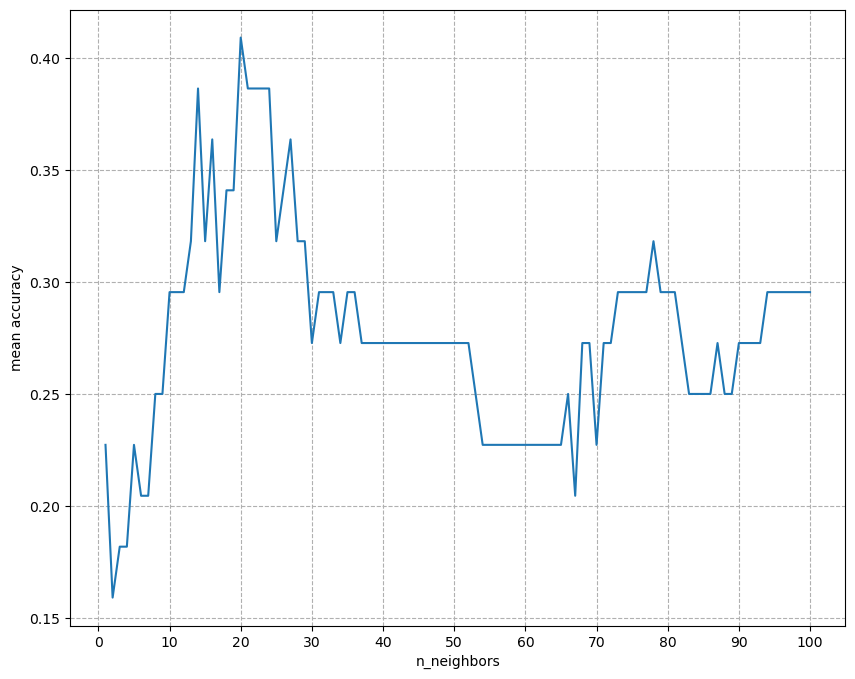

In [179]:
plt.figure(figsize=(10, 8))
plt.plot(range(1, max_kernels + 1), accur)
plt.xticks(range(0, max_kernels + 1,10))
plt.xlabel('n_neighbors')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

З графіку бачу, що найкраще значення параметра знаходиться в межах від 10 до 25 , тому що з такими кількостями сусідів маємо найвищі показники.


<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Використовуючи файл <a href="https://drive.google.com/file/d/1gxqzPQNlqrwrJI3zstMsvHQAbsdMPe-2/view?usp=drive_link" target="_blank">Data5.csv</a>:

1. Визначити кластер країн з найкращим розвитком (кластеризувати по Ie, Iec, Is; для k-середніх використати 4 кластера). Побудувати центри кластерів.
2. Провести кластеризацію по Сql, порахувати скільки країн потрапило в різні кластери, якщо порівнювати з п1.</p>
</div>


Згідно з методологією вимірювання сталого розвитку країн, сталий розвиток оцінюється за допомогою відповідного індексу у просторі трьох вимірів: економічного (Іес), екологічного (Іе) і соціально-інституціонального (Is). Цей індекс є вектором, норма якого визначає рівень сталого розвитку, а його просторове положення в системі координат (Iec,Ie,Is) характеризує міру «гармонійності» цього розвитку.

<details><summary>Натисніть тут, щоб побачити підказку до першого завдання</summary>

```python
# Зчитуємо заданий набір даних, зразу коригуючи
df = pd.read_csv(
    'Data5.csv', encoding='windows-1251', sep=';', decimal=','
).rename(columns={'Unnamed: 0': 'Country'})

df

```

</details>



In [184]:
df = pd.read_csv('Data5.csv', encoding='windows-1251', sep=';', decimal=',').rename(columns={'Unnamed: 0': 'Country'})
df

,Country,ISO,UA,Cql,Ie,Iec,Is
0,Albania,ALB,Албанія,0.973924,0.605348,0.538673,0.510113
1,Algeria,DZA,Алжир,0.782134,0.587219,0.348159,0.497986
2,Angola,AGO,Ангола,0.372344,0.274394,0.332117,0.346907
3,Argentina,ARG,Аргентина,0.883830,0.699685,0.281995,0.518820
4,Armenia,ARM,Вірменія,1.016499,0.718327,0.535648,0.486498
...,...,...,...,...,...,...,...
127,Uruguay,URY,Уруґвай,1.198779,0.612819,0.568067,0.648819
128,"Venezuela, Bolivarian Republic of",VEN,"Венесуела, Боліварська Республіка",0.703460,0.670452,0.249923,0.367244
129,Viet Nam,VNM,В'єтнам,0.553256,0.371843,0.393854,0.423359
130,Yemen,YEM,Ємен,0.364579,0.244049,0.357660,0.330743


<details><summary>Натисніть тут, щоб побачити підказку до другого завдання</summary>

Номери кластерів для першого і другого методів кластеризації зовсім не обовязково співпадатимуть. Щоб знайти відповідність, подивіться в які кластери з другого методу потрапляють центри кластерів з першого.

Порахувати скільки країн потрапило в різні кластери можна з використанням матриці невідповідностей (як аргументи поставти номери кластерів для першого і другого методів кластеризації).

</details>

In [205]:
kmeans_model = KMeans(n_clusters=4, random_state=1)
df['Cluster1'] = kmeans_model.fit_predict(df[['Ie','Iec','Is']])

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [207]:
kmeans_model.cluster_centers_

array([[0.26373834, 0.39763907, 0.40589422],
       [0.67025222, 0.51146735, 0.52570366],
       [0.50062486, 0.43545445, 0.47490056],
       [0.76853461, 0.66849294, 0.63963314]])

In [209]:
kmeans_model_Cql = KMeans(n_clusters=4, random_state=1)
df['Cluster_Cql'] = kmeans_model_Cql.fit_predict(df[['Cql']])

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [211]:
kmeans_model_Cql.cluster_centers_

array([[0.78804913],
       [1.06549338],
       [1.36157553],
       [0.47382721]])

In [215]:
df[['Country', 'Cluster1', 'Cluster_Cql']]

,Country,Cluster1,Cluster_Cql
0,Albania,1,1
1,Algeria,2,0
2,Angola,0,3
3,Argentina,1,0
4,Armenia,1,1
...,...,...,...
127,Uruguay,1,1
128,"Venezuela, Bolivarian Republic of",2,0
129,Viet Nam,0,3
130,Yemen,0,3


In [217]:
df[['Cluster1']].value_counts()

Cluster1
1           40
2           34
3           30
0           28
Name: count, dtype: int64

In [219]:
df[['Cluster_Cql']].value_counts()

Cluster_Cql
0              40
1              35
2              29
3              28
Name: count, dtype: int64

<h2>Виконав студент групи ІП-23 <br> Матвієнко Дарʼя</h2>
